# Heston Feature Extension


## Setup
_Run this cell first. It pulls the shared repo code and imports it._


In [ ]:
# === Setup: pull shared code and import (run first) ===
from google.colab import drive; drive.mount('/content/drive')
import os
REPO_URL = 'https://github.com/JosephOuyang/machine_learning_for_implied_volatility_forecasting.git'
REPO_DIR = '/content/repo'
if os.path.isdir(REPO_DIR):
    os.system(f'cd {REPO_DIR} && git pull -q')
else:
    os.system(f'git clone -q {REPO_URL} {REPO_DIR}')
import sys; sys.path.insert(0, REPO_DIR)
from shared.setup import *   # imports, seeds, logger, Drive mount


# Heston Feature Extension


### Heston Feature Extension


In [ ]:
# =============================================================================
# CELL 16.0 — Week 16 START
# Extension: Heston as Feature (Pure NN Sequential only)
#
# Professor Schafer (meeting transcript):
#   "What if instead of trying to fit through this residual, somebody used
#    the Heston price as a feature in the model?"
#   "The relationship isn't that simple."
#   "I would work on setting it up so that the Heston prediction is included
#    as a feature and then see how that compares."
#
# This week implements one extension only:
#   Features: (moneyness, tau, sigma_heston)   in_dim=3
#   Label:    sigma_market                     (direct prediction, not residual)
#   Mode:     sequential only
#   Horizons: same_day, one_day_ahead, five_day_ahead
#
# Comparison baseline: Pure NN Sequential from Cell 15.10
#   That model used in_dim=2 (moneyness, tau) with label=sigma_market.
#   This model adds sigma_heston as a third input, allowing the NN to learn
#   any nonlinear function of the Heston IV rather than a fixed additive
#   correction as in Heston+NN (Cells 15.8/15.9).
#
# Additive framing vs feature framing:
#   Heston+NN:       pred = sigma_heston + NN(moneyness, tau)
#   This extension:  pred = NN(moneyness, tau, sigma_heston)
# =============================================================================

BASE_DIR = "/content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs"
run_dir_w16, fig_dir_w16 = start_run("week16_heston_as_feature",
                                      base_dir=BASE_DIR)
print("run_dir_w16:", run_dir_w16)
print("fig_dir_w16:", fig_dir_w16)

save_json(run_dir_w16, "params", {
    "week": 16,
    "goal": "Heston IV as direct input feature — sequential training, all three horizons",
    "motivation": (
        "Professor Schafer: use Heston prediction as a feature rather than "
        "an additive correction, so the NN can learn nonlinear interactions."
    ),
    "architecture": "JiangNN(in_dim=3): 32->16->8->1, ReLU, Xavier Normal",
    "features": ["moneyness", "tau", "sigma_heston"],
    "label": "sigma_market (label_pure_nn — same as Pure NN)",
    "sigma_model_col": None,
    "training_mode": "sequential only",
    "horizons": ["same_day", "one_day_ahead", "five_day_ahead"],
    "hyperparams": {
        "N_EPOCHS":   N_EPOCHS,
        "BATCH_SIZE": BATCH_SIZE,
        "LR":         LR,
        "ADAM_EPS":   ADAM_EPS,
    },
    "split": "R-split 70/30 same-day | full day t for ahead horizons",
    "comparison_baselines": {
        "Pure_NN_Sequential":   "Cell 15.10 — in_dim=2, no Heston input",
        "Heston+NN_Sequential": "Cell 15.9  — in_dim=2, additive residual",
    },
    "rmse_units": "percentage points of IV (RMSE * 100, matches Jiang Tables 4 & 5)",
    "dataset": run_dir_w15 + "/amer_with_labels.csv",
})

save_notes(run_dir_w16, """
Week 16 deliverable:
- Confirm sigma_heston column present in df_amer (built in Cell 15.4).
- Run HestonFeature Sequential same-day.       → Cell 16.1
- Run HestonFeature Sequential one-day-ahead.  → Cell 16.2
- Run HestonFeature Sequential five-day-ahead. → Cell 16.3
- Compare all three horizons to Pure NN Sequential and Heston+NN Sequential baselines.
- Summary table + bar chart + daily OOS time-series.  → Cell 16.4
""")

# Verify sigma_heston is present before proceeding
required = ['moneyness', 'tau', 'sigma_market', 'sigma_heston',
            'label_pure_nn', 'moneyness_bucket', 'date']
missing = [c for c in required if c not in df_amer.columns]
if missing:
    print(f"❌ Missing columns: {missing}")
    print("   Re-run Cells 15.1–15.4 or reload amer_with_labels.csv first.")
else:
    print(f"All required columns present ✅")
    print(f"df_amer: {len(df_amer):,} rows | "
          f"sigma_heston non-null: {df_amer['sigma_heston'].notna().sum():,}")
    print(f"sigma_heston range: {df_amer['sigma_heston'].min():.4f} – "
          f"{df_amer['sigma_heston'].max():.4f}")

FEATURE_COLS_W16 = ['moneyness', 'tau', 'sigma_heston']
ext16_results = {}

print("Week 16 logger ready ✅")

run_dir_w16: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week16_heston_as_feature/20260606-195614
fig_dir_w16: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week16_heston_as_feature/20260606-195614/figures
All required columns present ✅
df_amer: 2,489,361 rows | sigma_heston non-null: 2,489,361
sigma_heston range: 0.0000 – 1.0127
Week 16 logger ready ✅


In [ ]:
# =============================================================================
# CELL 16.1 — HestonFeature Sequential: same-day
# =============================================================================

res, rmse = run_framework(
    df_amer,
    label_col       = 'label_pure_nn',   # sigma_market
    fw_name         = 'HestonFeature',
    sigma_model_col = None,              # direct prediction — no additive correction
    training_mode   = 'sequential',
    run_dir         = run_dir_w16,
    fig_dir         = fig_dir_w16,
    horizon         = 'same_day',
    in_dim          = 3,
    feature_cols    = FEATURE_COLS_W16,
)
ext16_results['HestonFeature_sequential_same_day'] = (res, rmse)
print(f"\nHestonFeature Sequential same-day OOS RMSE: {rmse:.4f}%")


HestonFeature | sequential | same_day
Resumed from index 1920
  [1921/1926] 2023-08-24  n_train=1066  in-sample=1.224%  oos=1.092%  avg_oos=0.921%  rate=12.5/min  ETA=0min
  [1922/1926] 2023-08-25  n_train= 928  in-sample=1.616%  oos=1.775%  avg_oos=0.921%  rate=13.3/min  ETA=0min
  [1923/1926] 2023-08-28  n_train= 919  in-sample=1.178%  oos=1.286%  avg_oos=0.921%  rate=13.6/min  ETA=0min
  [1924/1926] 2023-08-29  n_train= 923  in-sample=1.066%  oos=1.104%  avg_oos=0.922%  rate=13.8/min  ETA=0min
  [1925/1926] 2023-08-30  n_train= 871  in-sample=1.143%  oos=1.460%  avg_oos=0.922%  rate=14.1/min  ETA=0min
  [1926/1926] 2023-08-31  n_train=1045  in-sample=1.360%  oos=1.392%  avg_oos=0.922%  rate=13.8/min  ETA=0min

HestonFeature_sequential_same_day
  Table 4 in-sample:     0.851%
  Table 5 out-of-sample: 0.922%

HestonFeature Sequential same-day OOS RMSE: 0.9221%


In [ ]:
# =============================================================================
# CELL 16.2 — HestonFeature Sequential: one-day-ahead
# =============================================================================

res, rmse = run_framework(
    df_amer,
    label_col       = 'label_pure_nn',
    fw_name         = 'HestonFeature',
    sigma_model_col = None,
    training_mode   = 'sequential',
    run_dir         = run_dir_w16,
    fig_dir         = fig_dir_w16,
    horizon         = 'one_day_ahead',
    in_dim          = 3,
    feature_cols    = FEATURE_COLS_W16,
)
ext16_results['HestonFeature_sequential_one_day_ahead'] = (res, rmse)
print(f"\nHestonFeature Sequential one-day-ahead OOS RMSE: {rmse:.4f}%")


HestonFeature | sequential | one_day_ahead
Resumed from index 1920
  [1921/1926] 2023-08-24  n_train=1524  in-sample=1.240%  oos=9.944%  avg_oos=1.698%  rate=9.0/min  ETA=1min
  [1922/1926] 2023-08-25  n_train=1327  in-sample=1.827%  oos=1.882%  avg_oos=1.698%  rate=9.5/min  ETA=0min
  [1923/1926] 2023-08-28  n_train=1314  in-sample=1.542%  oos=1.816%  avg_oos=1.698%  rate=9.8/min  ETA=0min
  [1924/1926] 2023-08-29  n_train=1320  in-sample=1.440%  oos=1.717%  avg_oos=1.698%  rate=9.9/min  ETA=0min
  [1925/1926] 2023-08-30  n_train=1245  in-sample=1.579%  oos=4.233%  avg_oos=1.699%  rate=10.0/min  ETA=0min

HestonFeature_sequential_one_day_ahead
  Table 4 in-sample:     0.904%
  Table 5 out-of-sample: 1.699%

HestonFeature Sequential one-day-ahead OOS RMSE: 1.6994%


In [ ]:
# =============================================================================
# CELL 16.3 — Load All Results
# Loads Week 15 baselines and Week 16 HestonFeature results into one dict.
# Extracts daily OOS series, mean in-sample, mean OOS, and bucket RMSEs.
# =============================================================================

import json, os
import numpy as np
import pandas as pd

run_dir_w15 = "runs/week15_jiang_replication/20260602-150926"
run_dir_w16 = "runs/week15_jiang_replication/20260602-150926"


# ── File map ──────────────────────────────────────────────────────────────────
FILE_MAP = {
    'BS+NN Indep':       (run_dir_w15, 'results_BS+NN_independent_same_day.json'),
    'BS+NN Seq':         (run_dir_w15, 'results_BS+NN_sequential_same_day.json'),
    'Heston+NN Indep':   (run_dir_w15, 'results_Heston+NN_independent_same_day.json'),
    'Heston+NN Seq':     (run_dir_w15, 'results_Heston+NN_sequential_same_day.json'),
    'Pure NN Seq':       (run_dir_w15, 'results_Pure_NN_sequential_same_day.json'),
    'Pure NN Seq 1d':    (run_dir_w15, 'results_Pure_NN_sequential_one_day_ahead.json'),
    'HestonFeat Seq':    (run_dir_w16, 'results_HestonFeature_sequential_same_day.json'),
    'HestonFeat Seq 1d': (run_dir_w16, 'results_HestonFeature_sequential_one_day_ahead.json'),
}

raw = {}
for label, (rdir, fname) in FILE_MAP.items():
    path = os.path.join(rdir, fname)
    if os.path.exists(path):
        with open(path) as f:
            raw[label] = json.load(f)
        print(f"  Loaded: {label}")
    else:
        print(f"  ⚠️  Not found: {fname}")

print(f"\nLoaded {len(raw)}/{len(FILE_MAP)} result files ✅")

# ── Extract summaries ─────────────────────────────────────────────────────────
def extract(d):
    daily      = d['daily']
    oos_series = np.array([r['outofsample_rmse_pct'] for r in daily])
    ins_series = np.array([r['insample_rmse_pct']    for r in daily])

    buckets = {'ITM': [], 'ATM': [], 'OTM': []}
    for r in daily:
        br = r.get('bucket_rmses', {})
        for b in buckets:
            if b in br and br[b] is not None:
                buckets[b].append(br[b])

    bucket_means = {
        b: float(np.mean(v)) if v else np.nan
        for b, v in buckets.items()
    }

    return {
        'mean_ins':     float(d['mean_insample_rmse_pct']),
        'mean_oos':     float(d['mean_outofsample_rmse_pct']),
        'oos_series':   oos_series,
        'ins_series':   ins_series,
        'bucket_means': bucket_means,
        'n_days':       len(daily),
    }

results_w16 = {label: extract(d) for label, d in raw.items()}

print("\nSummary:")
print(f"{'Label':22s}  {'In-sample':>10s}  {'OOS':>10s}  "
      f"{'ITM':>8s}  {'ATM':>8s}  {'OTM':>8s}")
print("-" * 75)
for label, r in results_w16.items():
    bm = r['bucket_means']
    print(f"{label:22s}  {r['mean_ins']:>10.3f}  {r['mean_oos']:>10.3f}  "
          f"{bm['ITM']:>8.3f}  {bm['ATM']:>8.3f}  {bm['OTM']:>8.3f}")

save_json(run_dir_w16, "results_summary_loaded", {
    label: {
        'mean_ins':     r['mean_ins'],
        'mean_oos':     r['mean_oos'],
        'bucket_means': r['bucket_means'],
        'n_days':       r['n_days'],
    }
    for label, r in results_w16.items()
})
print("\nCell 16.3 complete ✅")

  Loaded: BS+NN Indep
  Loaded: BS+NN Seq
  Loaded: Heston+NN Indep
  Loaded: Heston+NN Seq
  Loaded: Pure NN Seq
  Loaded: Pure NN Seq 1d
  Loaded: HestonFeat Seq
  Loaded: HestonFeat Seq 1d

Loaded 8/8 result files ✅

Summary:
Label                    In-sample         OOS       ITM       ATM       OTM
---------------------------------------------------------------------------
BS+NN Indep                  2.588       2.637     2.996     1.481     2.411
BS+NN Seq                    1.577       1.699     1.772     0.578     1.884
Heston+NN Indep              1.805       1.843     2.242     0.939     1.421
Heston+NN Seq                1.255       1.321     1.455     0.782     1.267
Pure NN Seq                  1.623       1.731     1.816     0.613     1.900
Pure NN Seq 1d               1.605       2.212     2.335     1.171     2.195
HestonFeat Seq               0.851       0.922     1.010     0.573     0.891
HestonFeat Seq 1d            0.904       1.699     2.062     0.814     1.280

C

,Framework,Horizon,IS (%),OOS (%),ITM,ATM,OTM
0,BS+NN Indep,same-day,2.588,2.637,2.996,1.481,2.411
1,BS+NN Seq,same-day,1.577,1.699,1.772,0.578,1.884
2,Heston+NN Indep,same-day,1.805,1.843,2.242,0.939,1.421
3,Heston+NN Seq,same-day,1.255,1.321,1.455,0.782,1.267
4,Pure NN Seq,same-day,1.623,1.731,1.816,0.613,1.900
5,HestonFeat Seq,same-day,0.851,0.922,1.010,0.573,0.891
6,Pure NN Seq 1d,1-day-ahead,1.605,2.212,2.335,1.171,2.195
7,HestonFeat Seq 1d,1-day-ahead,0.904,1.699,2.062,0.814,1.280


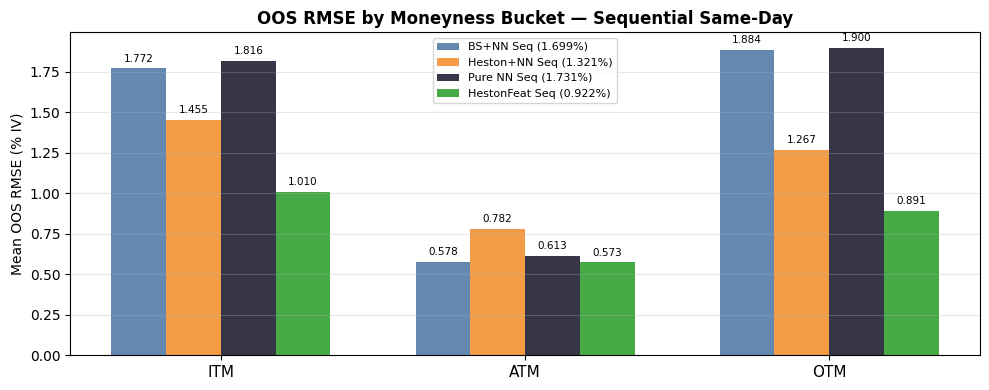

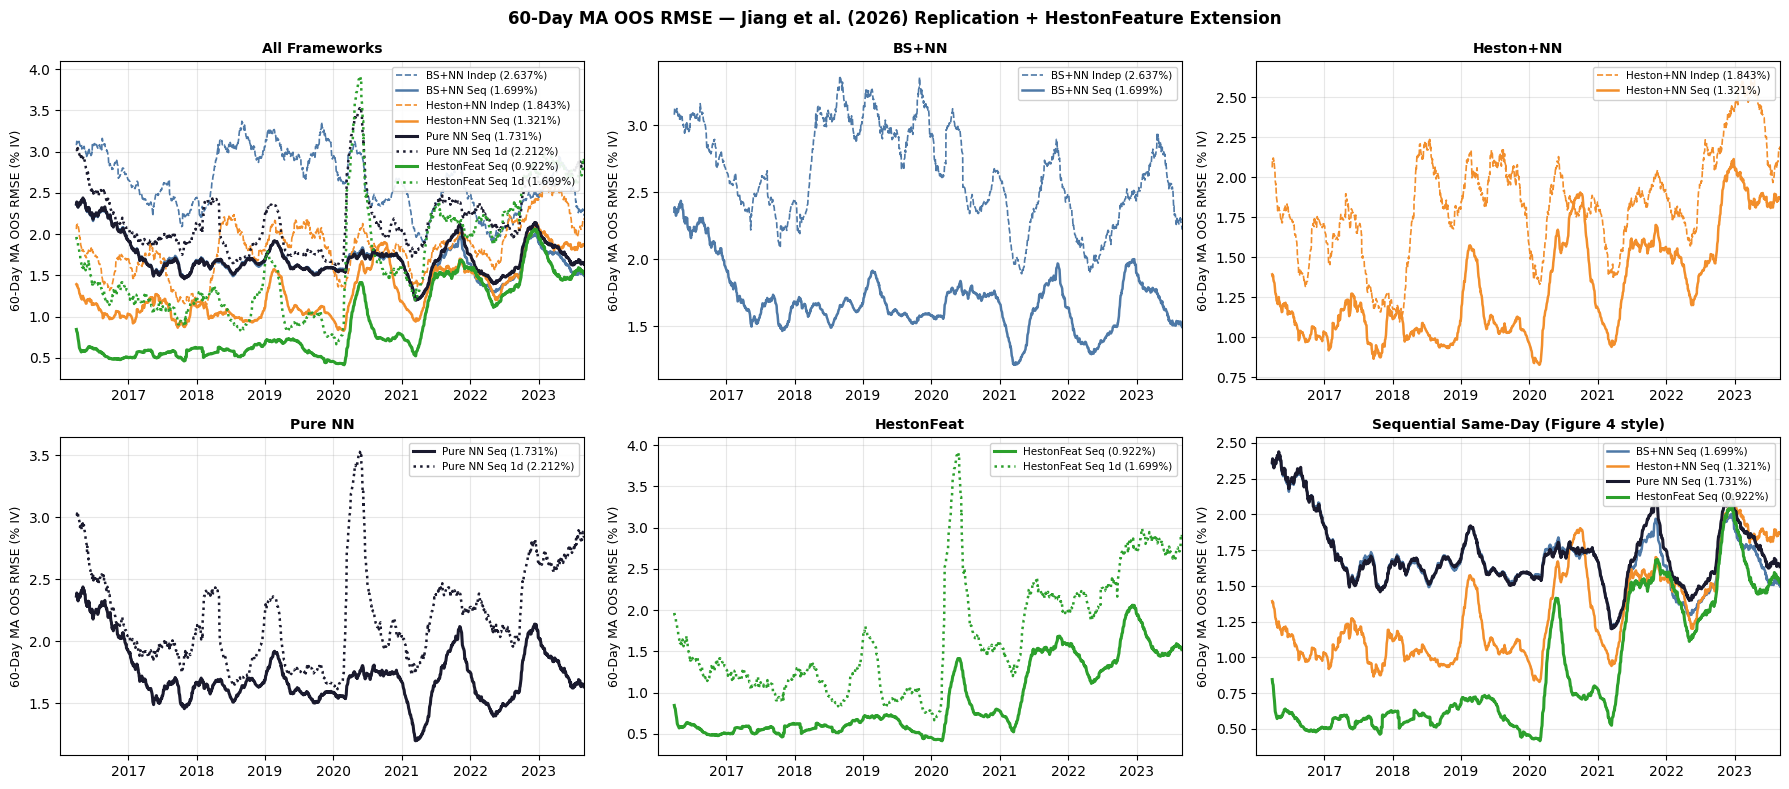

Saved: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week16_heston_as_feature/20260606-195614/figures/viz_60dayMA_combined.png


In [ ]:
# =============================================================================
# CELL 16.4 — Visualizations
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import os

# ── Shared config ─────────────────────────────────────────────────────────────
STYLE = {
    'BS+NN Indep':       dict(color='#4e79a7', ls='--', lw=1.2),
    'BS+NN Seq':         dict(color='#4e79a7', ls='-',  lw=1.8),
    'Heston+NN Indep':   dict(color='#f28e2b', ls='--', lw=1.2),
    'Heston+NN Seq':     dict(color='#f28e2b', ls='-',  lw=1.8),
    'Pure NN Seq':       dict(color='#1a1a2e', ls='-',  lw=2.2),
    'Pure NN Seq 1d':    dict(color='#1a1a2e', ls=':',  lw=1.8),
    'HestonFeat Seq':    dict(color='#2ca02c', ls='-',  lw=2.2),
    'HestonFeat Seq 1d': dict(color='#2ca02c', ls=':',  lw=1.8),
}
X_MIN, X_MAX = pd.Timestamp('2016-01-04'), pd.Timestamp('2023-08-31')

def ma_series(label, w=60):
    d    = raw[label]
    dates = pd.to_datetime([r['date'] for r in d['daily']])
    oos   = np.array([r['outofsample_rmse_pct'] for r in d['daily']])
    ma    = np.full(len(oos), np.nan)
    for i in range(w - 1, len(oos)):
        ma[i] = oos[i - w + 1 : i + 1].mean()
    return dates, ma

def fmt_ax(ax, title):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylabel("60-Day MA OOS RMSE (% IV)", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3)

def plot_lines(ax, labels):
    for label in labels:
        if label not in results_w16:
            continue
        dates, ma = ma_series(label)
        s = STYLE[label]
        ax.plot(dates, ma, label=f"{label} ({results_w16[label]['mean_oos']:.3f}%)",
                color=s['color'], ls=s['ls'], lw=s['lw'])

# ── VIZ A: RMSE summary table (pandas styler) ─────────────────────────────────
SAME_DAY = ['BS+NN Indep', 'BS+NN Seq', 'Heston+NN Indep', 'Heston+NN Seq',
            'Pure NN Seq', 'HestonFeat Seq']
AHEAD    = ['Pure NN Seq 1d', 'HestonFeat Seq 1d']

def tbl_row(label, horizon):
    r  = results_w16[label]
    bm = r['bucket_means']
    return {
        'Framework': label, 'Horizon': horizon,
        'IS (%)':  round(r['mean_ins'], 3),
        'OOS (%)': round(r['mean_oos'], 3),
        'ITM':     round(bm['ITM'], 3) if not np.isnan(bm['ITM']) else np.nan,
        'ATM':     round(bm['ATM'], 3) if not np.isnan(bm['ATM']) else np.nan,
        'OTM':     round(bm['OTM'], 3) if not np.isnan(bm['OTM']) else np.nan,
    }

df_tbl = pd.DataFrame(
    [tbl_row(l, 'same-day')   for l in SAME_DAY if l in results_w16] +
    [tbl_row(l, '1-day-ahead') for l in AHEAD    if l in results_w16]
)

display(df_tbl.style
    .format("{:.3f}", subset=['IS (%)','OOS (%)','ITM','ATM','OTM'], na_rep='—')
    .apply(lambda col: ['background: #e6f4ea' if 'HestonFeat' in str(v) else ''
                        for v in df_tbl['Framework']], axis=0)
    .set_caption("RMSE (%) — AM to AM | R-splitting | Jiang et al. (2026) + Extension"))

# ── VIZ B: Bucket RMSE bar chart ──────────────────────────────────────────────
SEQ_SD = ['BS+NN Seq', 'Heston+NN Seq', 'Pure NN Seq', 'HestonFeat Seq']
COLORS = ['#4e79a7', '#f28e2b', '#1a1a2e', '#2ca02c']
BUCKETS = ['ITM', 'ATM', 'OTM']

fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(3), 0.18
for i, (label, color) in enumerate(zip(SEQ_SD, COLORS)):
    if label not in results_w16:
        continue
    vals = [results_w16[label]['bucket_means'].get(b, np.nan) for b in BUCKETS]
    bars = ax.bar(x + (i - 1.5) * w, vals, width=w, color=color,
                  label=f"{label} ({results_w16[label]['mean_oos']:.3f}%)", alpha=0.88)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(BUCKETS, fontsize=11)
ax.set_ylabel("Mean OOS RMSE (% IV)"); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_title("OOS RMSE by Moneyness Bucket — Sequential Same-Day", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir_w16, "viz_bucket_rmse_bar.png"), dpi=150, bbox_inches='tight')
plt.show()

# ── VIZ C/D/E: 60-day MA curves ───────────────────────────────────────────────
GROUPS = {
    'BS+NN':      ['BS+NN Indep', 'BS+NN Seq'],
    'Heston+NN':  ['Heston+NN Indep', 'Heston+NN Seq'],
    'Pure NN':    ['Pure NN Seq', 'Pure NN Seq 1d'],
    'HestonFeat': ['HestonFeat Seq', 'HestonFeat Seq 1d'],
}

# All curves + panel subplots in one figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("60-Day MA OOS RMSE — Jiang et al. (2026) Replication + HestonFeature Extension",
             fontsize=12, fontweight='bold')

# Top-left: all curves together
plot_lines(axes[0, 0], list(STYLE.keys()))
fmt_ax(axes[0, 0], "All Frameworks")

# Top-right + bottom row: one panel per group
for ax, (gname, labels) in zip(list(axes[0, 1:]) + list(axes[1, :]), GROUPS.items()):
    plot_lines(ax, labels)
    fmt_ax(ax, gname)

# Bottom-right: sequential same-day only (closest to Jiang Figure 4)
axes[1, -1].cla()
plot_lines(axes[1, -1], SEQ_SD)
fmt_ax(axes[1, -1], "Sequential Same-Day (Figure 4 style)")

plt.tight_layout()
fig_path = os.path.join(fig_dir_w16, "viz_60dayMA_combined.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", fig_path)

In [ ]:
# =============================================================================
# CELL 16.5 — Side-by-side RMSE Comparison: Ours vs Jiang Tables 4–5
# =============================================================================
# Focus:
#   Table 4: In-sample RMSE
#     - Panel B: Same day, R-splitting, AM to AM
#     - Panel C: One day ahead, AM to AM
#
#   Table 5: Out-of-sample RMSE
#     - Panel B: Same day, R-splitting, AM to AM
#     - Panel C: One day ahead, AM to AM
#
# Our values are from the Week 15/16 summary table.
# Jiang values are hardcoded from Tables 4 and 5.
# =============================================================================

import os
import numpy as np
import pandas as pd

OUT_DIR = "runs/week16_hestonfeature_extension"

# ── Our results from first table ──────────────────────────────────────────────
OURS = {
    ("BS+NN Indep",      "same-day"):    (2.588, 2.637),
    ("BS+NN Seq",        "same-day"):    (1.577, 1.699),
    ("Heston+NN Indep",  "same-day"):    (1.805, 1.843),
    ("Heston+NN Seq",    "same-day"):    (1.255, 1.321),
    ("Pure NN Seq",      "same-day"):    (1.623, 1.731),
    ("HestonFeat Seq",   "same-day"):    (0.851, 0.922),

    ("Pure NN Seq",      "1-day-ahead"): (1.605, 2.212),
    ("HestonFeat Seq",   "1-day-ahead"): (0.904, 1.699),
}

# ── Jiang et al. values from Tables 4 and 5 ───────────────────────────────────
# format: (paper_in_sample, paper_oos)
PAPER = {
    # Table 4 Panel B + Table 5 Panel B: Same day, R-splitting, AM to AM
    ("BS+NN Indep",      "same-day"):    (2.818, 3.219),
    ("BS+NN Seq",        "same-day"):    (2.298, 2.826),
    ("Heston+NN Indep",  "same-day"):    (2.789, 2.867),
    ("Heston+NN Seq",    "same-day"):    (2.233, 2.366),
    ("Pure NN Seq",      "same-day"):    (2.213, 2.345),

    # Table 4 Panel C + Table 5 Panel C: One day ahead, AM to AM
    ("BS+NN Indep",      "1-day-ahead"): (2.685, 4.051),
    ("BS+NN Seq",        "1-day-ahead"): (2.275, 3.408),
    ("Heston+NN Indep",  "1-day-ahead"): (2.600, 3.519),
    ("Heston+NN Seq",    "1-day-ahead"): (2.184, 2.927),
    ("Pure NN Seq",      "1-day-ahead"): (2.172, 2.901),
}

def pct_diff(ours, paper):
    if pd.isna(paper):
        return np.nan
    return (ours - paper) / paper * 100

rows = []

for key, (our_in, our_oos) in OURS.items():
    framework, horizon = key
    paper_in, paper_oos = PAPER.get(key, (np.nan, np.nan))

    rows.append({
        "Framework": framework,
        "Horizon": horizon,
        "Our In-Sample": our_in,
        "Paper In-Sample": paper_in,
        "In-Sample Diff": our_in - paper_in if not pd.isna(paper_in) else np.nan,
        "In-Sample % Diff": pct_diff(our_in, paper_in),
        "Our OOS": our_oos,
        "Paper OOS": paper_oos,
        "OOS Diff": our_oos - paper_oos if not pd.isna(paper_oos) else np.nan,
        "OOS % Diff": pct_diff(our_oos, paper_oos),
        "Note": "Week 16 extension" if "HestonFeat" in framework else "Jiang framework",
    })

df_cmp = pd.DataFrame(rows)

# ── Pretty formatted one-table display ───────────────────────────────────────
disp = df_cmp.copy()

num_cols = [
    "Our In-Sample", "Paper In-Sample", "In-Sample Diff",
    "Our OOS", "Paper OOS", "OOS Diff",
]

for c in num_cols:
    disp[c] = disp[c].map(lambda x: "—" if pd.isna(x) else f"{x:.3f}")

for c in ["In-Sample % Diff", "OOS % Diff"]:
    disp[c] = disp[c].map(lambda x: "—" if pd.isna(x) else f"{x:+.2f}%")

styled = (
    disp.style
    .hide(axis="index")
    .set_caption(
        "RMSE Side-by-side Comparison — Ours vs Jiang et al. Tables 4–5"
    )
    .set_properties(**{
        "text-align": "center",
        "border": "1px solid #999",
        "padding": "6px",
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#2f4053"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #222"),
                ("padding", "6px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #999"),
                ("padding", "6px"),
            ],
        },
    ])
)

display(styled)

# ── Save outputs ─────────────────────────────────────────────────────────────
os.makedirs(OUT_DIR, exist_ok=True)

out_path = os.path.join(
    OUT_DIR,
    "rmse_side_by_side_ours_vs_jiang_tables4_5.csv"
)

df_cmp.to_csv(out_path, index=False)

print("\nSaved:")
print(" ", out_path)

Framework,Horizon,Our In-Sample,Paper In-Sample,In-Sample Diff,In-Sample % Diff,Our OOS,Paper OOS,OOS Diff,OOS % Diff,Note
BS+NN Indep,same-day,2.588,2.818,-0.230,-8.16%,2.637,3.219,-0.582,-18.08%,Jiang framework
BS+NN Seq,same-day,1.577,2.298,-0.721,-31.38%,1.699,2.826,-1.127,-39.88%,Jiang framework
Heston+NN Indep,same-day,1.805,2.789,-0.984,-35.28%,1.843,2.867,-1.024,-35.72%,Jiang framework
Heston+NN Seq,same-day,1.255,2.233,-0.978,-43.80%,1.321,2.366,-1.045,-44.17%,Jiang framework
Pure NN Seq,same-day,1.623,2.213,-0.590,-26.66%,1.731,2.345,-0.614,-26.18%,Jiang framework
HestonFeat Seq,same-day,0.851,—,—,—,0.922,—,—,—,Week 16 extension
Pure NN Seq,1-day-ahead,1.605,2.172,-0.567,-26.10%,2.212,2.901,-0.689,-23.75%,Jiang framework
HestonFeat Seq,1-day-ahead,0.904,—,—,—,1.699,—,—,—,Week 16 extension



Saved:
  runs/week16_hestonfeature_extension/rmse_side_by_side_ours_vs_jiang_tables4_5.csv


In [ ]:
# =============================================================================
# CELL 17.0 — Week 17 START
# Comprehensive Framework Comparison: 18 Frameworks, In-Sample + Out-of-Sample
#
# Objective:
#   Aggregate the full battery of frameworks across all three horizons, then
#   build visualizations to observe relationships and draw conclusions:
#     - Independent vs Sequential vs Pure NN vs HestonFeature extension
#     - RMSE by moneyness bucket, separated into Call and Put
#     - How forecast horizon (same-day / 1-day / 5-day) drives RMSE
#
#   Each "framework" is one (model x training x horizon) configuration and
#   carries BOTH an in-sample RMSE (Table 4 style) and an out-of-sample RMSE
#   (Table 5 style).
#
# The 18 frameworks:
#   SAME-DAY:       BS+NN Indep, BS+NN Seq, Heston+NN Indep, Heston+NN Seq,
#                   Pure NN Seq, HestonFeature Seq (extension)
#   ONE-DAY-AHEAD:  BS+NN Indep, BS+NN Seq, Heston+NN Indep, Heston+NN Seq,
#                   Pure NN Seq, HestonFeature Seq (extension)
#   FIVE-DAY-AHEAD: BS+NN Indep, BS+NN Seq, Heston+NN Indep, Heston+NN Seq,
#                   Pure NN Seq, HestonFeature Seq (extension)
#
# This cell only creates the Week 17 run folder. Result JSONs will be placed
# into it manually, and their file paths supplied to the loading cell that follows.
# =============================================================================

BASE_DIR = "/content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs"
run_dir_w17, fig_dir_w17 = start_run("week17_comprehensive_framework_comparison",
                                      base_dir=BASE_DIR)
print("run_dir_w17:", run_dir_w17)
print("fig_dir_w17:", fig_dir_w17)
print("\nWeek 17 folder created ✅")
print("Drop the result JSONs into run_dir_w17, then pass their paths to the next cell.")

run_dir_w17: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week17_comprehensive_framework_comparison/20260614-012435
fig_dir_w17: /content/drive/MyDrive/Options Pricing Research (S26)/machine_learning_for_options_pricing_and_implied_volatility/runs/week17_comprehensive_framework_comparison/20260614-012435/figures

Week 17 folder created ✅
Drop the result JSONs into run_dir_w17, then pass their paths to the next cell.


In [ ]:
# =============================================================================
# CELL 17.1 — Two Comparison Tables: Ours vs Jiang et al.
#   Table A: In-sample (Table 4) + Out-of-sample (Table 5), AM to AM, R-splitting
#   Table B: Out-of-sample by Call/Put x ITM/ATM/OTM (Table 6), AM to AM, R-splitting
#
# Reads the result JSONs produced by run_framework() (jiang_common.py):
#   results_{model}_{mode}_{horizon}.json
#       -> mean_insample_rmse_pct, mean_outofsample_rmse_pct, daily[...]
#   table6_{model}_{mode}_{horizon}.json
#       -> table6_summary {C/P x ITM/ATM/OTM}, daily_callput_bucket_rmses[...]
#
# Paper-value rule: paper columns hold exactly what Jiang et al. printed; our
# columns hold exactly what our runs produced. The paper reports 1-day and
# 5-day in-sample jointly (Panel C), so those in-sample paper values are the
# same for both horizons. HestonFeature is our Week 16 extension and has no
# paper counterpart (shown as —).
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
from IPython.display import display, HTML

RUN_DIR_W17 = "runs/week17_comprehensive_framework_comparison/20260614-012435"

# ── Model-name spellings used in the JSON filenames ───────────────────────────
# results_(BS_NN|Heston_NN|HestonFeature|Pure_NN)_(independent|sequential)_(same_day|one_day_ahead|five_day_ahead).json
FNAME_MODEL = {
    "BS+NN":         "BS_NN",
    "Heston+NN":     "Heston_NN",
    "Pure NN":       "Pure_NN",
    "HestonFeature": "HestonFeature",
}

def _load_json(prefix, model_key, mode, horizon):
    """Load a result file; return parsed dict or None if absent."""
    fname = f"{prefix}_{FNAME_MODEL[model_key]}_{mode}_{horizon}.json"
    path = os.path.join(RUN_DIR_W17, fname)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

def _mean_rmse(d, which):
    """which: 'insample' or 'outofsample'. Prefer precomputed mean, else average daily."""
    if d is None:
        return np.nan
    key = f"mean_{which}_rmse_pct"
    if key in d and d[key] is not None:
        return float(d[key])
    field = f"{which}_rmse_pct"
    vals = [r[field] for r in d.get("daily", []) if r.get(field) is not None]
    return float(np.mean(vals)) if vals else np.nan

def _callput_summary(d):
    """
    Pull the sample-averaged Call/Put x bucket RMSEs.
    Prefer table6_summary (precomputed); else average daily_callput_bucket_rmses.
    """
    blank = {cp: {mb: np.nan for mb in ["ITM", "ATM", "OTM"]} for cp in ["C", "P"]}
    if d is None:
        return blank
    if "table6_summary" in d and d["table6_summary"]:
        s = d["table6_summary"]
        return {cp: {mb: (np.nan if s.get(cp, {}).get(mb) is None else float(s[cp][mb]))
                     for mb in ["ITM", "ATM", "OTM"]} for cp in ["C", "P"]}
    acc = {cp: {mb: [] for mb in ["ITM", "ATM", "OTM"]} for cp in ["C", "P"]}
    for r in d.get("daily_callput_bucket_rmses", []):
        cpb = r.get("callput_bucket_rmses", {})
        for cp in ["C", "P"]:
            for mb in ["ITM", "ATM", "OTM"]:
                v = cpb.get(cp, {}).get(mb)
                if v is not None:
                    acc[cp][mb].append(v)
    return {cp: {mb: (float(np.mean(vals)) if vals else np.nan) for mb, vals in acc[cp].items()}
            for cp in ["C", "P"]}

def pct_diff(ours, paper):
    if np.isnan(ours) or np.isnan(paper) or paper == 0:
        return np.nan
    return (ours - paper) / paper * 100.0


# =============================================================================
# TABLE A — In-sample (Table 4) + Out-of-sample (Table 5), AM to AM, R-split
# =============================================================================
# Paper: Table 4 Panel B + Table 5 Panel B (same-day); Panel C (1-day in/OOS);
# 5-day in-sample == 1-day (shared Panel C), OOS from Table 5 Panel D.
# Each entry: (paper_in_sample, paper_oos). NaN where the paper has no entry.

PAPER_45 = {
    ("BS+NN",         "independent", "same_day"):       (2.818, 3.219),
    ("BS+NN",         "sequential",  "same_day"):       (2.298, 2.826),
    ("Heston+NN",     "independent", "same_day"):       (2.789, 2.867),
    ("Heston+NN",     "sequential",  "same_day"):       (2.233, 2.366),
    ("Pure NN",       "sequential",  "same_day"):       (2.213, 2.345),
    ("HestonFeature", "sequential",  "same_day"):       (np.nan, np.nan),

    ("BS+NN",         "independent", "one_day_ahead"):  (2.685, 4.051),
    ("BS+NN",         "sequential",  "one_day_ahead"):  (2.275, 3.408),
    ("Heston+NN",     "independent", "one_day_ahead"):  (2.600, 3.519),
    ("Heston+NN",     "sequential",  "one_day_ahead"):  (2.184, 2.927),
    ("Pure NN",       "sequential",  "one_day_ahead"):  (2.172, 2.901),
    ("HestonFeature", "sequential",  "one_day_ahead"):  (np.nan, np.nan),

    ("BS+NN",         "independent", "five_day_ahead"): (2.685, 4.813),
    ("BS+NN",         "sequential",  "five_day_ahead"): (2.275, 4.104),
    ("Heston+NN",     "independent", "five_day_ahead"): (2.600, 5.341),
    ("Heston+NN",     "sequential",  "five_day_ahead"): (2.184, 3.766),
    ("Pure NN",       "sequential",  "five_day_ahead"): (2.172, 3.680),
    ("HestonFeature", "sequential",  "five_day_ahead"): (np.nan, np.nan),
}

HORIZON_LABEL = {"same_day": "same-day",
                 "one_day_ahead": "1-day-ahead",
                 "five_day_ahead": "5-day-ahead"}

GRID_A = [
    ("BS+NN", "independent"), ("BS+NN", "sequential"),
    ("Heston+NN", "independent"), ("Heston+NN", "sequential"),
    ("Pure NN", "sequential"), ("HestonFeature", "sequential"),
]

rows_a = []
for horizon in ["same_day", "one_day_ahead", "five_day_ahead"]:
    for model, mode in GRID_A:
        d = _load_json("results", model, mode, horizon)
        our_in  = _mean_rmse(d, "insample")
        our_oos = _mean_rmse(d, "outofsample")
        paper_in, paper_oos = PAPER_45[(model, mode, horizon)]
        rows_a.append({
            "Framework":  f"{model} {'Indep' if mode == 'independent' else 'Seq'}",
            "Horizon":    HORIZON_LABEL[horizon],
            "Our IS":     our_in,
            "Paper IS":   paper_in,
            "IS Diff":    our_in - paper_in,
            "IS % Diff":  pct_diff(our_in, paper_in),
            "Our OOS":    our_oos,
            "Paper OOS":  paper_oos,
            "OOS Diff":   our_oos - paper_oos,
            "OOS % Diff": pct_diff(our_oos, paper_oos),
            "_extension": model == "HestonFeature",
        })

df_a = pd.DataFrame(rows_a)

def _fmt_a(df):
    d = df.copy()
    for c in ["Our IS", "Paper IS", "IS Diff", "Our OOS", "Paper OOS", "OOS Diff"]:
        d[c] = d[c].map(lambda x: "—" if pd.isna(x) else f"{x:.3f}")
    for c in ["IS % Diff", "OOS % Diff"]:
        d[c] = d[c].map(lambda x: "—" if pd.isna(x) else f"{x:+.2f}%")
    return d.drop(columns=["_extension"])

styled_a = (
    _fmt_a(df_a).style
    .hide(axis="index")
    .set_caption("Table A — In-Sample (Table 4) & Out-of-Sample (Table 5): Ours vs Jiang et al. | AM to AM, R-splitting")
    .apply(lambda _: ['background-color: #e6f4ea' if ext else '' for ext in df_a["_extension"]], axis=0)
    .set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "15px"),
                                          ("font-weight", "bold"), ("padding", "10px")]},
        {"selector": "th", "props": [("background-color", "#2f4053"), ("color", "white"),
                                     ("font-weight", "bold"), ("text-align", "center"),
                                     ("border", "1px solid #222"), ("padding", "6px")]},
        {"selector": "td", "props": [("text-align", "center"), ("border", "1px solid #999"), ("padding", "5px")]},
    ])
)
display(styled_a)


# =============================================================================
# TABLE B — Out-of-sample RMSE by Call/Put x ITM/ATM/OTM (Table 6), AM to AM, R-split
# =============================================================================
# Paper: Jiang Table 6 Panel B (Same day, R-splitting), sequential models.
# Layout mirrors the paper: Call ITM/ATM/OTM then Put ITM/ATM/OTM.

PAPER_T6 = {  # model -> {'C': {ITM,ATM,OTM}, 'P': {ITM,ATM,OTM}}
    "BS+NN":     {"C": {"ITM": 3.622, "ATM": 1.128, "OTM": 2.654},
                  "P": {"ITM": 2.429, "ATM": 1.038, "OTM": 2.999}},
    "Heston+NN": {"C": {"ITM": 2.407, "ATM": 0.786, "OTM": 2.640},
                  "P": {"ITM": 2.519, "ATM": 0.804, "OTM": 2.743}},
    "Pure NN":   {"C": {"ITM": 2.456, "ATM": 0.805, "OTM": 2.571},
                  "P": {"ITM": 2.420, "ATM": 0.732, "OTM": 2.725}},
    # HestonFeature has no paper counterpart (extension)
}

GRID_B = ["BS+NN", "Heston+NN", "Pure NN", "HestonFeature"]
CELLS = [("C", "ITM"), ("C", "ATM"), ("C", "OTM"),
         ("P", "ITM"), ("P", "ATM"), ("P", "OTM")]

rows_b = []
for model in GRID_B:
    d = _load_json("table6", model, "sequential", "same_day")
    ours = _callput_summary(d)
    paper = PAPER_T6.get(model)
    row = {"Framework": model}
    for cp, mb in CELLS:
        col = f"{'Call' if cp == 'C' else 'Put'} {mb}"
        row[col] = ours[cp][mb]
        row[col + "_paper"] = paper[cp][mb] if paper else np.nan
    row["_extension"] = (model == "HestonFeature")
    rows_b.append(row)

df_b = pd.DataFrame(rows_b)

# ── Render as a paper-style HTML table: ours over paper ───────────────────────
def _cell_html(o, p, is_ext):
    o_str = "—" if pd.isna(o) else f"{o:.3f}"
    if is_ext or pd.isna(p):
        return (f"<div style='line-height:1.35'>"
                f"<div style='font-weight:500;color:#1a1a1a'>{o_str}</div>"
                f"<div style='font-size:11px;color:#888'>—</div></div>")
    p_str = f"{p:.3f}"
    ours_better = (not pd.isna(o)) and (o < p)   # lower RMSE is better
    color = "#0F6E56" if ours_better else "#A32D2D"
    bg    = "#E1F5EE" if ours_better else "#FCEBEB"
    return (f"<div style='line-height:1.35'>"
            f"<div style='font-weight:500;color:#1a1a1a'>{o_str}</div>"
            f"<div style='font-size:11px;color:{color};background:{bg};"
            f"padding:1px 6px;border-radius:6px;display:inline-block'>{p_str}</div></div>")

header = """
<div style='font-family:-apple-system,Segoe UI,sans-serif;margin-bottom:24px'>
  <div style='font-size:15px;font-weight:600;margin-bottom:8px'>
    Table B &mdash; Out-of-Sample RMSE by Moneyness, Call vs Put (Table 6): Ours vs Jiang et al.
  </div>
  <div style='font-size:12px;color:#666;margin-bottom:10px'>
    AM to AM, R-splitting, same-day, sequential. Top number = ours &nbsp;|&nbsp;
    <span style='color:#0F6E56;background:#E1F5EE;padding:1px 6px;border-radius:6px'>green = paper (ours better)</span>
    &nbsp;
    <span style='color:#A32D2D;background:#FCEBEB;padding:1px 6px;border-radius:6px'>red = paper (paper better)</span>
  </div>
  <table style='border-collapse:collapse;font-size:13px'>
    <thead>
      <tr style='background:#2f4053;color:white'>
        <th rowspan='2' style='padding:8px 12px;text-align:left;border:1px solid #222'>Framework</th>
        <th colspan='3' style='padding:8px;border:1px solid #222'>Call</th>
        <th colspan='3' style='padding:8px;border:1px solid #222'>Put</th>
      </tr>
      <tr style='background:#3d5468;color:white;font-size:12px'>
        <th style='padding:4px 10px;border:1px solid #222'>ITM</th>
        <th style='padding:4px 10px;border:1px solid #222'>ATM</th>
        <th style='padding:4px 10px;border:1px solid #222'>OTM</th>
        <th style='padding:4px 10px;border:1px solid #222'>ITM</th>
        <th style='padding:4px 10px;border:1px solid #222'>ATM</th>
        <th style='padding:4px 10px;border:1px solid #222'>OTM</th>
      </tr>
    </thead>
    <tbody>
"""

body = ""
for _, r in df_b.iterrows():
    ext = bool(r["_extension"])
    name = r["Framework"] + (" <span style='font-size:10px;color:#2ca02c'>(ext)</span>" if ext else "")
    cells = ""
    for cp, mb in CELLS:
        col = f"{'Call' if cp == 'C' else 'Put'} {mb}"
        cells += (f"<td style='padding:6px 10px;text-align:center;border:1px solid #ccc'>"
                  f"{_cell_html(r[col], r[col + '_paper'], ext)}</td>")
    body += (f"<tr><td style='padding:8px 12px;font-weight:500;border:1px solid #ccc'>{name}</td>{cells}</tr>")

footer = "</tbody></table></div>"
display(HTML(header + body + footer))


# ── Save both tables to disk ──────────────────────────────────────────────────
df_a.drop(columns=["_extension"]).to_csv(
    os.path.join(RUN_DIR_W17, "table45_comparison_ours_vs_jiang.csv"), index=False)
df_b.drop(columns=["_extension"]).to_csv(
    os.path.join(RUN_DIR_W17, "table6_comparison_callput_ours_vs_jiang.csv"), index=False)

print("\nSaved:")
print(" ", os.path.join(RUN_DIR_W17, "table45_comparison_ours_vs_jiang.csv"))
print(" ", os.path.join(RUN_DIR_W17, "table6_comparison_callput_ours_vs_jiang.csv"))

Framework,Horizon,Our IS,Paper IS,IS Diff,IS % Diff,Our OOS,Paper OOS,OOS Diff,OOS % Diff
BS+NN Indep,same-day,2.588,2.818,-0.230,-8.17%,2.637,3.219,-0.582,-18.08%
BS+NN Seq,same-day,1.591,2.298,-0.707,-30.78%,1.714,2.826,-1.112,-39.36%
Heston+NN Indep,same-day,1.785,2.789,-1.004,-35.98%,1.818,2.867,-1.049,-36.58%
Heston+NN Seq,same-day,1.330,2.233,-0.903,-40.46%,1.387,2.366,-0.979,-41.38%
Pure NN Seq,same-day,1.607,2.213,-0.606,-27.38%,1.724,2.345,-0.621,-26.50%
HestonFeature Seq,same-day,0.801,—,—,—,0.863,—,—,—
BS+NN Indep,1-day-ahead,2.293,2.685,-0.392,-14.62%,2.819,4.051,-1.232,-30.40%
BS+NN Seq,1-day-ahead,1.632,2.275,-0.643,-28.27%,2.174,3.408,-1.234,-36.22%
Heston+NN Indep,1-day-ahead,1.605,2.600,-0.995,-38.25%,2.071,3.519,-1.448,-41.15%
Heston+NN Seq,1-day-ahead,1.361,2.184,-0.823,-37.68%,1.753,2.927,-1.174,-40.11%



Saved:
  runs/week17_comprehensive_framework_comparison/20260614-012435/table45_comparison_ours_vs_jiang.csv
  runs/week17_comprehensive_framework_comparison/20260614-012435/table6_comparison_callput_ours_vs_jiang.csv


In [ ]:
# =============================================================================
# CELL 17.2 — Table 6 (Call/Put x ITM/ATM/OTM) for ALL frameworks we ran.
#   Ours on top of every cell. Paper value shown underneath ONLY where the
#   paper reports it (Jiang Table 6 = sequential, same-day, R-splitting:
#   BS+NN Seq, Heston+NN Seq, Pure NN Seq). Everything else = ours only.
#   Reads table6_{model}_{mode}_{horizon}.json -> table6_summary {C/P x bucket}.
#   Adds a per-framework Avg column (mean of the 6 our-values).
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
from IPython.display import display, HTML

RUN_DIR_W17 = "runs/week17_comprehensive_framework_comparison/20260614-012435"

FNAME_MODEL = {
    "BS+NN":         "BS_NN",
    "Heston+NN":     "Heston_NN",
    "Pure NN":       "Pure_NN",
    "HestonFeature": "HestonFeature",
}

def _load_table6(model_key, mode, horizon):
    fname = f"table6_{FNAME_MODEL[model_key]}_{mode}_{horizon}.json"
    path = os.path.join(RUN_DIR_W17, fname)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

def _callput_summary(d):
    """Sample-averaged Call/Put x bucket RMSEs. Prefer table6_summary; else average daily."""
    blank = {cp: {mb: np.nan for mb in ["ITM", "ATM", "OTM"]} for cp in ["C", "P"]}
    if d is None:
        return blank
    if d.get("table6_summary"):
        s = d["table6_summary"]
        return {cp: {mb: (np.nan if s.get(cp, {}).get(mb) is None else float(s[cp][mb]))
                     for mb in ["ITM", "ATM", "OTM"]} for cp in ["C", "P"]}
    acc = {cp: {mb: [] for mb in ["ITM", "ATM", "OTM"]} for cp in ["C", "P"]}
    for r in d.get("daily_callput_bucket_rmses", []):
        cpb = r.get("callput_bucket_rmses", {})
        for cp in ["C", "P"]:
            for mb in ["ITM", "ATM", "OTM"]:
                v = cpb.get(cp, {}).get(mb)
                if v is not None:
                    acc[cp][mb].append(v)
    return {cp: {mb: (float(np.mean(vals)) if vals else np.nan) for mb, vals in acc[cp].items()}
            for cp in ["C", "P"]}

# ── Paper values: Jiang Table 6 Panel B (Same day, R-splitting). Only the three
#    sequential models the paper reports. Keyed by (model, mode, horizon). ──────
PAPER_T6 = {
    ("BS+NN", "sequential", "same_day"):
        {"C": {"ITM": 3.622, "ATM": 1.128, "OTM": 2.654},
         "P": {"ITM": 2.429, "ATM": 1.038, "OTM": 2.999}},
    ("Heston+NN", "sequential", "same_day"):
        {"C": {"ITM": 2.407, "ATM": 0.786, "OTM": 2.640},
         "P": {"ITM": 2.519, "ATM": 0.804, "OTM": 2.743}},
    ("Pure NN", "sequential", "same_day"):
        {"C": {"ITM": 2.456, "ATM": 0.805, "OTM": 2.571},
         "P": {"ITM": 2.420, "ATM": 0.732, "OTM": 2.725}},
}

GRID = [
    ("BS+NN",         "independent", "BS+NN Indep"),
    ("BS+NN",         "sequential",  "BS+NN Seq"),
    ("Heston+NN",     "independent", "Heston+NN Indep"),
    ("Heston+NN",     "sequential",  "Heston+NN Seq"),
    ("Pure NN",       "sequential",  "Pure NN Seq"),
    ("HestonFeature", "sequential",  "HestonFeature Seq"),
]

HORIZON_PANELS = [
    ("same_day",       "Panel A: Same day (R-splitting)"),
    ("one_day_ahead",  "Panel B: One day ahead"),
    ("five_day_ahead", "Panel C: Five days ahead"),
]

CELLS = [("C", "ITM"), ("C", "ATM"), ("C", "OTM"),
         ("P", "ITM"), ("P", "ATM"), ("P", "OTM")]

def _cell_html(o, p):
    """o = our value, p = paper value (or NaN). Paper shown only when present."""
    o_str = "—" if (o is None or np.isnan(o)) else f"{o:.3f}"
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return f"<div style='font-weight:500;color:#1a1a1a'>{o_str}</div>"
    p_str = f"{p:.3f}"
    ours_better = (o is not None) and (not np.isnan(o)) and (o < p)
    color = "#0F6E56" if ours_better else "#A32D2D"
    bg    = "#E1F5EE" if ours_better else "#FCEBEB"
    return (f"<div style='line-height:1.35'>"
            f"<div style='font-weight:500;color:#1a1a1a'>{o_str}</div>"
            f"<div style='font-size:11px;color:{color};background:{bg};"
            f"padding:1px 6px;border-radius:6px;display:inline-block'>{p_str}</div></div>")

long_rows = []

header = """
<div style='font-family:-apple-system,Segoe UI,sans-serif;margin-bottom:24px'>
  <div style='font-size:15px;font-weight:600;margin-bottom:4px'>
    Table 6 (All Frameworks) &mdash; Out-of-Sample RMSE (%) by Moneyness, Call vs Put
  </div>
  <div style='font-size:12px;color:#666;margin-bottom:10px'>
    AM to AM, R-splitting. Top number = ours. Paper value shown beneath only where
    Jiang et al. report it (sequential, same-day):
    <span style='color:#0F6E56;background:#E1F5EE;padding:1px 6px;border-radius:6px'>green = ours better</span>
    &nbsp;
    <span style='color:#A32D2D;background:#FCEBEB;padding:1px 6px;border-radius:6px'>red = paper better</span>.
    HestonFeature is the Week 16 extension. Avg = mean of the six cells.
  </div>
  <table style='border-collapse:collapse;font-size:13px'>
    <thead>
      <tr style='background:#2f4053;color:white'>
        <th rowspan='2' style='padding:8px 12px;text-align:left;border:1px solid #222'>Framework</th>
        <th colspan='3' style='padding:8px;border:1px solid #222'>Call</th>
        <th colspan='3' style='padding:8px;border:1px solid #222'>Put</th>
        <th rowspan='2' style='padding:8px 12px;border:1px solid #222'>Avg</th>
      </tr>
      <tr style='background:#3d5468;color:white;font-size:12px'>
        <th style='padding:4px 10px;border:1px solid #222'>ITM</th>
        <th style='padding:4px 10px;border:1px solid #222'>ATM</th>
        <th style='padding:4px 10px;border:1px solid #222'>OTM</th>
        <th style='padding:4px 10px;border:1px solid #222'>ITM</th>
        <th style='padding:4px 10px;border:1px solid #222'>ATM</th>
        <th style='padding:4px 10px;border:1px solid #222'>OTM</th>
      </tr>
    </thead>
    <tbody>
"""

body = ""
for horizon, panel_label in HORIZON_PANELS:
    body += (f"<tr><td colspan='8' style='padding:7px 12px;background:#eef1f4;"
             f"font-weight:600;border:1px solid #ccc'>{panel_label}</td></tr>")

    for model, mode, label in GRID:
        d = _load_table6(model, mode, horizon)
        ours = _callput_summary(d)
        paper = PAPER_T6.get((model, mode, horizon))   # None if paper has no row
        is_ext = (model == "HestonFeature")
        name = label + (" <span style='font-size:10px;color:#2ca02c'>(ext)</span>" if is_ext else "")

        rec = {"panel": panel_label, "framework": label}
        cells = ""
        for cp, mb in CELLS:
            o = ours[cp][mb]
            p = paper[cp][mb] if paper else np.nan
            cells += (f"<td style='padding:6px 10px;text-align:center;border:1px solid #ccc'>"
                      f"{_cell_html(o, p)}</td>")
            rec[f"{'Call' if cp=='C' else 'Put'} {mb}"] = o
            if paper:
                rec[f"{'Call' if cp=='C' else 'Put'} {mb} (paper)"] = p

        our_vals = [ours[cp][mb] for cp, mb in CELLS]
        valid = [v for v in our_vals if v is not None and not np.isnan(v)]
        avg = float(np.mean(valid)) if valid else np.nan
        avg_str = "—" if np.isnan(avg) else f"{avg:.3f}"
        cells += (f"<td style='padding:6px 10px;text-align:center;border:1px solid #ccc;"
                  f"font-weight:600;background:#f7f9fb'>{avg_str}</td>")
        rec["Avg"] = avg

        body += (f"<tr><td style='padding:7px 12px;border:1px solid #ccc'>{name}</td>{cells}</tr>")
        long_rows.append(rec)

footer = "</tbody></table></div>"
display(HTML(header + body + footer))

# ── Save to CSV ───────────────────────────────────────────────────────────────
df_all = pd.DataFrame(long_rows)
csv_path = os.path.join(RUN_DIR_W17, "table6_all_frameworks_callput.csv")
df_all.to_csv(csv_path, index=False)
print("\nSaved:", csv_path)


Saved: runs/week17_comprehensive_framework_comparison/20260614-012435/table6_all_frameworks_callput.csv


In [ ]:
# =============================================================================
# CELL 17.3 — Analysis: where does the error concentrate, and who wins?
#   Answers four questions from the table6_*.json files:
#     (1) Which moneyness bucket is hardest? (ITM vs ATM vs OTM)
#     (2) Calls vs Puts — which is predicted better?
#     (3) Which framework has the lowest overall RMSE?
#     (4) Does HestonFeature actually win?
#   All numbers are sample-averaged OOS RMSE (%), AM to AM, R-splitting.
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
from IPython.display import display, HTML

RUN_DIR_W17 = "runs/week17_comprehensive_framework_comparison/20260614-012435"

FNAME_MODEL = {
    "BS+NN": "BS_NN", "Heston+NN": "Heston_NN",
    "Pure NN": "Pure_NN", "HestonFeature": "HestonFeature",
}
GRID = [
    ("BS+NN", "independent", "BS+NN Indep"),
    ("BS+NN", "sequential",  "BS+NN Seq"),
    ("Heston+NN", "independent", "Heston+NN Indep"),
    ("Heston+NN", "sequential",  "Heston+NN Seq"),
    ("Pure NN", "sequential",  "Pure NN Seq"),
    ("HestonFeature", "sequential", "HestonFeature Seq"),
]
HORIZONS = ["same_day", "one_day_ahead", "five_day_ahead"]
BUCKETS = ["ITM", "ATM", "OTM"]

def _load_summary(model, mode, horizon):
    path = os.path.join(RUN_DIR_W17, f"table6_{FNAME_MODEL[model]}_{mode}_{horizon}.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    s = d.get("table6_summary")
    if not s:
        return None
    return {cp: {mb: (np.nan if s.get(cp, {}).get(mb) is None else float(s[cp][mb]))
                 for mb in BUCKETS} for cp in ["C", "P"]}

# ── Collect every cell into a tidy long table ─────────────────────────────────
recs = []
for horizon in HORIZONS:
    for model, mode, label in GRID:
        s = _load_summary(model, mode, horizon)
        if s is None:
            continue
        for cp in ["C", "P"]:
            for mb in BUCKETS:
                recs.append({
                    "framework": label, "horizon": horizon,
                    "cp": "Call" if cp == "C" else "Put",
                    "bucket": mb, "rmse": s[cp][mb],
                })
df = pd.DataFrame(recs)

if df.empty:
    print("No table6_*.json files found in", RUN_DIR_W17)
else:
    def show(title, series, fmt="{:.3f}"):
        print(f"\n{title}")
        for k, v in series.items():
            print(f"   {k:<22} {fmt.format(v)}%" if not pd.isna(v) else f"   {k:<22} —")

    # (1) Moneyness: which bucket is hardest, averaged over everything
    by_bucket = df.groupby("bucket")["rmse"].mean().reindex(BUCKETS)
    show("(1) Mean OOS RMSE by moneyness bucket (lower = easier to predict):", by_bucket)
    best_b, worst_b = by_bucket.idxmin(), by_bucket.idxmax()
    print(f"   -> {best_b} is the easiest, {worst_b} is the hardest.")

    # (2) Call vs Put
    by_cp = df.groupby("cp")["rmse"].mean()
    show("(2) Mean OOS RMSE by option type:", by_cp)
    print(f"   -> {by_cp.idxmin()}s are predicted slightly better on average.")

    # (3) Framework ranking (overall mean across all cells & horizons)
    by_fw = df.groupby("framework")["rmse"].mean().sort_values()
    show("(3) Mean OOS RMSE by framework (all buckets & horizons, ranked):", by_fw)
    print(f"   -> Lowest overall: {by_fw.idxmin()}.")

    # (3b) Framework ranking restricted to same-day only (cleaner apples-to-apples)
    by_fw_sd = (df[df.horizon == "same_day"].groupby("framework")["rmse"]
                .mean().sort_values())
    show("(3b) Same-day only, by framework:", by_fw_sd)

    # (4) Does HestonFeature win? count cells where it's the lowest
    wins, total = 0, 0
    for (horizon, cp, mb), grp in df.groupby(["horizon", "cp", "bucket"]):
        if grp["rmse"].notna().sum() == 0:
            continue
        total += 1
        if grp.loc[grp["rmse"].idxmin(), "framework"] == "HestonFeature Seq":
            wins += 1
    print(f"\n(4) HestonFeature Seq has the lowest RMSE in {wins}/{total} cells "
          f"(across horizon x call/put x bucket).")
    print(f"   Overall rank of HestonFeature: "
          f"#{list(by_fw.index).index('HestonFeature Seq') + 1} of {len(by_fw)} frameworks.")

    # ── Compact heatmap-style summary table: framework x bucket (call+put avg) ──
    pivot = (df.groupby(["framework", "bucket"])["rmse"].mean()
             .unstack("bucket").reindex(columns=BUCKETS)
             .reindex([g[2] for g in GRID]))
    pivot["Overall"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("Overall")

    def _heat(s):
        lo, hi = np.nanmin(s.values), np.nanmax(s.values)
        out = []
        for v in s:
            if pd.isna(v):
                out.append("")
            else:
                t = 0 if hi == lo else (v - lo) / (hi - lo)   # 0=best(green) 1=worst(red)
                r = int(225 + 30 * t); g = int(245 - 90 * t); b = int(230 - 90 * t)
                out.append(f"background-color: rgb({r},{g},{b})")
        return out

    styled = (pivot.style
              .format("{:.3f}", na_rep="—")
              .apply(_heat, axis=0)
              .set_caption("Mean OOS RMSE (%) — framework x moneyness (Call & Put averaged, all horizons). Greener = lower error.")
              .set_table_styles([
                  {"selector": "caption", "props": [("caption-side", "top"),
                   ("font-weight", "bold"), ("padding", "8px"), ("font-size", "13px")]},
                  {"selector": "th", "props": [("background-color", "#2f4053"),
                   ("color", "white"), ("padding", "6px")]},
                  {"selector": "td", "props": [("text-align", "center"),
                   ("padding", "6px"), ("border", "1px solid #ddd")]},
              ]))
    display(styled)

    # ── Save all analysis outputs into the run folder ─────────────────────────
    OUT_DIR = os.path.join(RUN_DIR_W17, "analysis_17_3")
    os.makedirs(OUT_DIR, exist_ok=True)

    # 1) The tidy long table (raw data behind every number)
    df.to_csv(os.path.join(OUT_DIR, "rmse_long.csv"), index=False)

    # 2) The framework x bucket pivot (with Overall column)
    pivot.to_csv(os.path.join(OUT_DIR, "framework_by_bucket.csv"))

    # 3) The styled heatmap table as standalone HTML
    with open(os.path.join(OUT_DIR, "framework_by_bucket.html"), "w") as f:
        f.write(styled.to_html())

    # 4) The four text answers + rankings as JSON
    summary = {
        "run_dir": RUN_DIR_W17,
        "q1_by_bucket": by_bucket.round(4).to_dict(),
        "q1_easiest": best_b,
        "q1_hardest": worst_b,
        "q2_by_cp": by_cp.round(4).to_dict(),
        "q2_better": by_cp.idxmin(),
        "q3_by_framework": by_fw.round(4).to_dict(),
        "q3_lowest": by_fw.idxmin(),
        "q3b_same_day_by_framework": by_fw_sd.round(4).to_dict(),
        "q4_hestonfeature_wins": int(wins),
        "q4_total_cells": int(total),
        "q4_hestonfeature_overall_rank": list(by_fw.index).index("HestonFeature Seq") + 1,
        "q4_num_frameworks": len(by_fw),
    }
    with open(os.path.join(OUT_DIR, "analysis_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print(f"\n[saved] analysis outputs -> {OUT_DIR}")
    for fn in ["rmse_long.csv", "framework_by_bucket.csv",
               "framework_by_bucket.html", "analysis_summary.json"]:
        print(f"          {fn}")


(1) Mean OOS RMSE by moneyness bucket (lower = easier to predict):
   ITM                    2.224%
   ATM                    1.114%
   OTM                    1.763%
   -> ATM is the easiest, ITM is the hardest.

(2) Mean OOS RMSE by option type:
   Call                   1.701%
   Put                    1.700%
   -> Puts are predicted slightly better on average.

(3) Mean OOS RMSE by framework (all buckets & horizons, ranked):
   HestonFeature Seq      1.290%
   Heston+NN Seq          1.358%
   Heston+NN Indep        1.630%
   BS+NN Seq              1.685%
   Pure NN Seq            1.791%
   BS+NN Indep            2.448%
   -> Lowest overall: HestonFeature Seq.

(3b) Same-day only, by framework:
   HestonFeature Seq      0.770%
   Heston+NN Seq          1.148%
   BS+NN Seq              1.316%
   Pure NN Seq            1.328%
   Heston+NN Indep        1.498%
   BS+NN Indep            2.276%

(4) HestonFeature Seq has the lowest RMSE in 11/18 cells (across horizon x call/put x bucket).

bucket,ITM,ATM,OTM,Overall
framework,,,,
HestonFeature Seq,1.763,0.870,1.238,1.290
Heston+NN Seq,1.815,0.856,1.403,1.358
Heston+NN Indep,2.458,0.961,1.471,1.630
BS+NN Seq,2.041,1.061,1.952,1.685
Pure NN Seq,2.093,1.227,2.053,1.791
BS+NN Indep,3.175,1.708,2.460,2.448



[saved] analysis outputs -> runs/week17_comprehensive_framework_comparison/20260614-012435/analysis_17_3
          rmse_long.csv
          framework_by_bucket.csv
          framework_by_bucket.html
          analysis_summary.json


In [ ]:
# =============================================================================
# CELL 17.3.5 — Shared helpers for the 60-day moving-average OOS RMSE plots.
#   Run this once; Cells 17.4 / 17.5 / 17.6 depend on it.
#
#   All series are OUT-OF-SAMPLE RMSE (%), matching Jiang Figs 3-6 (which are
#   all OOS). Rolling window = strict 60 trading days (min_periods=60), so each
#   curve starts ~3 months into the sample, as in the paper.
#
#   Focal-horizon styling: in each cell, the cell's own horizon is drawn bright,
#   and the other two horizons are drawn faint for context.
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

RUN_DIR_W17 = "runs/week17_comprehensive_framework_comparison/20260614-012435"

FNAME_MODEL = {
    "BS+NN": "BS_NN", "Heston+NN": "Heston_NN",
    "Pure NN": "Pure_NN", "HestonFeature": "HestonFeature",
}
HORIZONS = ["same_day", "one_day_ahead", "five_day_ahead"]
HORIZON_LABEL = {"same_day": "same-day", "one_day_ahead": "1-day-ahead",
                 "five_day_ahead": "5-day-ahead"}
WINDOW = 60   # trading days, strict (matches paper)

# ── cache: (model,mode,horizon) -> DataFrame indexed by date ──────────────────
_CACHE = {}

def _load_daily(model, mode, horizon):
    """Return a date-indexed DataFrame of the daily record, or None if absent."""
    key = (model, mode, horizon)
    if key in _CACHE:
        return _CACHE[key]
    path = os.path.join(RUN_DIR_W17, f"results_{FNAME_MODEL[model]}_{mode}_{horizon}.json")
    if not os.path.exists(path):
        _CACHE[key] = None
        return None
    with open(path) as f:
        d = json.load(f)
    rows = []
    for r in d["daily"]:
        row = {"date": pd.Timestamp(r["date"]),
               "oos": r["outofsample_rmse_pct"]}
        for b in ["ITM", "ATM", "OTM"]:
            row[f"b_{b}"] = r["bucket_rmses"].get(b)
        for cp in ["C", "P"]:
            for b in ["ITM", "ATM", "OTM"]:
                row[f"{cp}_{b}"] = r["callput_bucket_rmses"].get(cp, {}).get(b)
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("date").set_index("date")
    _CACHE[key] = df
    return df

def _ma(series):
    """Strict 60-day rolling mean."""
    return series.rolling(WINDOW, min_periods=WINDOW).mean()

def _style_axis(ax, title, ylabel="60-day MA OOS RMSE (%)"):
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=9)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.legend(fontsize=8, ncol=2, frameon=False, loc="upper right")

# Opacity / width for focal vs. off-horizon curves
FOCAL = dict(alpha=0.95, lw=1.8)
GHOST = dict(alpha=0.18, lw=1.0)

def _plot_line(ax, df, col, label, color, focal, dashed=False):
    if df is None or col not in df or df[col].isna().all():
        return
    style = FOCAL if focal else GHOST
    ax.plot(df.index, _ma(df[col]), color=color,
            linestyle="--" if dashed else "-",
            label=(label if focal else None), **style)


def make_horizon_figure(focal_horizon):
    """
    Build the full stacked figure for one focal horizon.
    Six axes, vertically stacked, never side-by-side.
    """
    others = [h for h in HORIZONS if h != focal_horizon]
    order = [focal_horizon] + others   # focal drawn last? we draw ghosts first

    fig, axes = plt.subplots(6, 1, figsize=(13, 26))
    fig.suptitle(
        f"60-Day Moving-Average Out-of-Sample RMSE  —  focal horizon: {HORIZON_LABEL[focal_horizon]}",
        fontsize=15, fontweight="bold", y=0.997)

    # ============================================================ Panel 1
    # Independent vs Sequential for BS+NN and Heston+NN
    ax = axes[0]
    P1 = [("BS+NN", "independent", "#c0392b"),
          ("BS+NN", "sequential",  "#e67e22"),
          ("Heston+NN", "independent", "#2471a3"),
          ("Heston+NN", "sequential",  "#27ae60")]
    for h in HORIZONS:                       # ghosts first, focal last
        focal = (h == focal_horizon)
        for model, mode, color in P1:
            lbl = f"{model} {'Indep' if mode=='independent' else 'Seq'}"
            _plot_line(ax, _load_daily(model, mode, h), "oos", lbl, color, focal)
    _style_axis(ax, "Panel 1 — Independent vs Sequential  (BS+NN, Heston+NN)")

    # ============================================================ Panel 2
    # All frameworks, sequential (plus BS/Heston independent for completeness)
    ax = axes[1]
    P2 = [("BS+NN", "sequential", "#e67e22"),
          ("Heston+NN", "sequential", "#27ae60"),
          ("Pure NN", "sequential", "#8e44ad"),
          ("HestonFeature", "sequential", "#16a085")]
    for h in HORIZONS:
        focal = (h == focal_horizon)
        for model, mode, color in P2:
            _plot_line(ax, _load_daily(model, mode, h), "oos", model, color, focal)
    _style_axis(ax, "Panel 2 — By Framework  (sequential)")

    # ============================================================ Panel 3
    # ITM/ATM/OTM bucket RMSE — HestonFeature Seq (solid) + Pure NN Seq (dashed)
    ax = axes[2]
    BUCKET_COLOR = {"ITM": "#c0392b", "ATM": "#27ae60", "OTM": "#2471a3"}
    P3 = [("HestonFeature", "sequential", False),
          ("Pure NN", "sequential", True)]
    for h in HORIZONS:
        focal = (h == focal_horizon)
        for model, mode, dashed in P3:
            df = _load_daily(model, mode, h)
            tag = "HestFeat" if model == "HestonFeature" else "PureNN"
            for b in ["ITM", "ATM", "OTM"]:
                _plot_line(ax, df, f"b_{b}", f"{b} ({tag})",
                           BUCKET_COLOR[b], focal, dashed=dashed)
    _style_axis(ax, "Panel 3 — Bucket RMSE: ITM / ATM / OTM   (solid = HestonFeature Seq, dashed = Pure NN Seq)")

    # ============================================================ Panel 4a
    # Call/Put x bucket — HestonFeature Seq (6 lines)
    ax = axes[3]
    CP_COLOR = {"C_ITM": "#1f4e79", "C_ATM": "#2e86c1", "C_OTM": "#85c1e9",
                "P_ITM": "#922b21", "P_ATM": "#c0392b", "P_OTM": "#e6948a"}
    CP_LABEL = {"C_ITM": "Call ITM", "C_ATM": "Call ATM", "C_OTM": "Call OTM",
                "P_ITM": "Put ITM",  "P_ATM": "Put ATM",  "P_OTM": "Put OTM"}
    for h in HORIZONS:
        focal = (h == focal_horizon)
        df = _load_daily("HestonFeature", "sequential", h)
        for col in CP_COLOR:
            _plot_line(ax, df, col, CP_LABEL[col], CP_COLOR[col], focal)
    _style_axis(ax, "Panel 4a — Call/Put × Bucket RMSE:  HestonFeature Seq")

    # ============================================================ Panel 4b
    # Call/Put x bucket — Pure NN Seq (6 lines)
    ax = axes[4]
    for h in HORIZONS:
        focal = (h == focal_horizon)
        df = _load_daily("Pure NN", "sequential", h)
        for col in CP_COLOR:
            _plot_line(ax, df, col, CP_LABEL[col], CP_COLOR[col], focal)
    _style_axis(ax, "Panel 4b — Call/Put × Bucket RMSE:  Pure NN Seq")

    # ============================================================ Legend note
    ax = axes[5]
    ax.axis("off")
    ax.text(0.0, 0.95,
            f"Reading these plots",
            fontsize=12, fontweight="bold", transform=ax.transAxes)
    note = (
        f"• All curves are 60-trading-day moving averages of out-of-sample RMSE (%), "
        f"matching Jiang Figs 3-6.\n"
        f"• Bright curves = the focal horizon for this cell ({HORIZON_LABEL[focal_horizon]}). "
        f"Faint curves = the other two horizons, shown for context.\n"
        f"• Strict 60-day window: each curve begins ~3 months into the 2016-2023 sample.\n"
        f"• Panel 3: color = bucket, solid = HestonFeature Seq, dashed = Pure NN Seq.\n"
        f"• Panels 4a/4b: blue family = calls, red family = puts; darker = ITM, lighter = OTM."
    )
    ax.text(0.0, 0.05, note, fontsize=10, transform=ax.transAxes, va="bottom",
            linespacing=1.6)

    fig.tight_layout(rect=[0, 0, 1, 0.992])
    out_png = os.path.join(RUN_DIR_W17, "figures",
                           f"ma60_oos_focal_{focal_horizon}.png")
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    fig.savefig(out_png, dpi=140, bbox_inches="tight")
    print("Saved:", out_png)
    plt.show()

print("Helpers loaded. Run 17.4 (same-day), 17.5 (1-day), 17.6 (5-day).")

Helpers loaded. Run 17.4 (same-day), 17.5 (1-day), 17.6 (5-day).
